<a href="https://colab.research.google.com/github/nk4544485-netizen/aerialproject/blob/main/Aerial.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

*Name : Nirmal Kumar

type  : individual *

aerial object dectection

####Drive Mount

In [ ]:
# 1. Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')
# List the contents of your Drive


# 2. Basic Imports
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# 3. Define Paths (Based on your provided dataset structure)
# Note: Update 'My Drive/Your_Folder_Name' if your dataset is inside a subfolder
base_path = '/content/drive/MyDrive/project6/test'
train_dir = os.path.join(base_path, 'TRAIN')
val_dir = os.path.join(base_path, 'VALID')
test_dir = os.path.join(base_path, 'TEST')

print("Environment Ready!")

Mounted at /content/drive
Environment Ready!


verifiying data set

In [ ]:
import os

# Update these folder names if they are different in your Drive
base_path = '/content/drive/MyDrive/classification_dataset'

def count_files(directory):
    for root, dirs, files in os.walk(directory):
        if not dirs: # Only subfolders like 'bird' or 'drone'
            print(f"Folder: {root.split('/')[-2]}/{root.split('/')[-1]} | Images: {len(files)}")

print("--- Verifying Image Counts ---")
count_files(base_path)

--- Verifying Image Counts ---


Data Preprocessing & Augmentation

In [ ]:
import os
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# --- 1. SET DIRECTORY PATHS (Matching your lowercase folders) ---
base_path = '/content/drive/MyDrive/project6'
train_dir = os.path.join(base_path, 'train')
val_dir   = os.path.join(base_path, 'valid')
test_dir  = os.path.join(base_path, 'test')

# --- 2. DEFINE IMAGE PARAMETERS ---
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

# --- 3. CONFIGURE DATA GENERATORS ---
# For Training: Rescale + Augmentation (to make the model smarter)
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

# For Validation/Test: Just Rescale
val_test_datagen = ImageDataGenerator(rescale=1./255)

# --- 4. INITIALIZE GENERATORS ---
print("Attempting to load images...")

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary'
)

val_generator = val_test_datagen.flow_from_directory(
    val_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary'
)

test_generator = val_test_datagen.flow_from_directory(
    test_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)

print("\n✅ All systems go! Ready for model building.")

Attempting to load images...
Found 2662 images belonging to 2 classes.
Found 442 images belonging to 2 classes.
Found 215 images belonging to 2 classes.

✅ All systems go! Ready for model building.


Model Building

In [ ]:
from tensorflow.keras import layers, models

def build_custom_cnn():
    model = models.Sequential([
        # Block 1: Input is 224x224 RGB
        layers.Conv2D(32, (3, 3), activation='relu', input_shape=(224, 224, 3)),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),

        # Block 2
        layers.Conv2D(64, (3, 3), activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),

        # Block 3
        layers.Conv2D(128, (3, 3), activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),

        # Flatten and Dense Layers
        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.5),  # Prevents overfitting
        layers.Dense(1, activation='sigmoid') # Sigmoid for Binary (0=Bird, 1=Drone)
    ])

    model.compile(optimizer='adam',
                  loss='binary_crossentropy',
                  metrics=['accuracy'])
    return model

custom_model = build_custom_cnn()
custom_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 222, 222, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 109, 109, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 52, 52, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,985 (42.61 MB)

 Trainable params: 11,169,537 (42.61 MB)

 Non-trainable params: 448 (1.75 KB)

Training Setup

In [ ]:
import os
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.applications import MobileNetV2  # <--- New Import

# --- 1. RE-ESTABLISH DATA PATHS ---
base_path = '/content/drive/MyDrive/project6'
train_dir = os.path.join(base_path, 'train')
val_dir   = os.path.join(base_path, 'valid')

# --- 2. RE-INITIALIZE GENERATORS ---
train_datagen = ImageDataGenerator(rescale=1./255, rotation_range=20, horizontal_flip=True)
val_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    train_dir, target_size=(224, 224), batch_size=32, class_mode='binary')

val_generator = val_datagen.flow_from_directory(
    val_dir, target_size=(224, 224), batch_size=32, class_mode='binary')

# --- 3. SWAPPED: TRANSFER LEARNING MODEL ---
# We use a pre-trained brain (MobileNetV2) instead of building from scratch
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model.trainable = False  # Keep the pre-trained knowledge locked

custom_model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(1, activation='sigmoid')
])

custom_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# --- 4. CALLBACKS & TRAINING ---
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
checkpoint = ModelCheckpoint('best_mobile_model.keras', monitor='val_accuracy', save_best_only=True)

print("🚀 Starting High-Performance Training... Stand by, partner.")
history = custom_model.fit(
    train_generator,
    epochs=10,
    validation_data=val_generator,
    callbacks=[early_stop, checkpoint]
)


Found 2662 images belonging to 2 classes.
Found 442 images belonging to 2 classes.
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
🚀 Starting High-Performance Training... Stand by, partner.
Epoch 1/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 111s 1s/step - accuracy: 0.9241 - loss: 0.1840 - val_accuracy: 0.9751 - val_loss: 0.0921
Epoch 2/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 58s 693ms/step - accuracy: 0.9752 - loss: 0.0689 - val_accuracy: 0.9638 - val_loss: 0.0886
Epoch 3/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 57s 679ms/step - accuracy: 0.9887 - loss: 0.0391 - val_accuracy: 0.9683 - val_loss: 0.0966
Epoch 4/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 57s 677ms/step - accuracy: 0.9857 - loss: 0.0400 - val_accuracy: 0.9706 - val_loss: 0.0950
Epoch 5/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 55s 657ms/step - accuracy: 0.9853 - loss: 0.0351 - val_accuracy: 0.9729 - val_loss: 0.0953


Performance Visualization (Learning Curves)

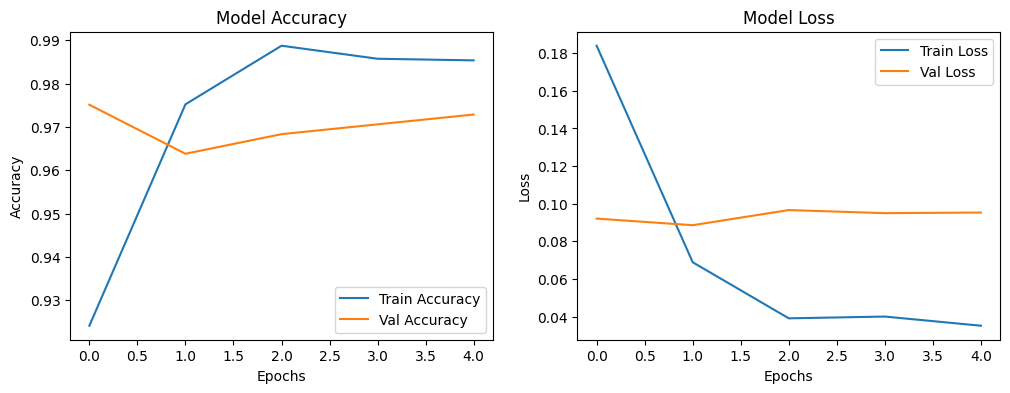

In [ ]:
import matplotlib.pyplot as plt

# Plotting Accuracy
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Plotting Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()

Final Evaluation (The Test Set)

In [ ]:
# 1. Load the Test Data (Ensure path is lowercase based on our previous fix)
test_dir = '/content/drive/MyDrive/project6/test'
test_datagen = tf.keras.preprocessing.image.ImageDataGenerator(rescale=1./255)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary',
    shuffle=False
)

# 2. Evaluate
test_loss, test_acc = custom_model.evaluate(test_generator)
print(f"\n🎯 Final Test Accuracy: {test_acc*100:.2f}%")

Found 215 images belonging to 2 classes.
7/7 ━━━━━━━━━━━━━━━━━━━━ 14s 2s/step - accuracy: 0.9674 - loss: 0.0769

🎯 Final Test Accuracy: 96.74%


Confusion Matrix

7/7 ━━━━━━━━━━━━━━━━━━━━ 12s 1s/step


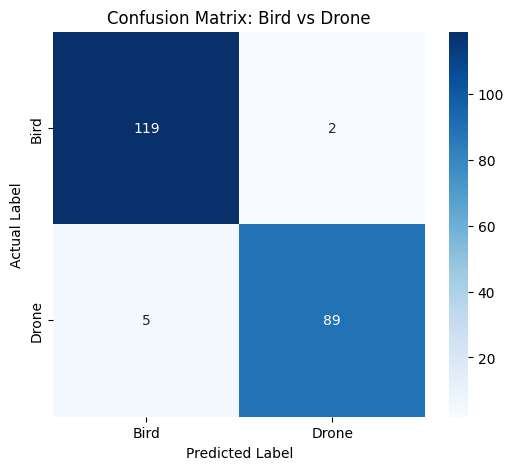


--- Detailed Classification Report ---
              precision    recall  f1-score   support

        Bird       0.96      0.98      0.97       121
       Drone       0.98      0.95      0.96        94

    accuracy                           0.97       215
   macro avg       0.97      0.97      0.97       215
weighted avg       0.97      0.97      0.97       215



In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import numpy as np

# 1. Get predictions from the test set
Y_pred = custom_model.predict(test_generator)
# Converting probabilities (0.0 to 1.0) into hard classes (0 or 1)
y_pred = (Y_pred > 0.5).astype(int).flatten()

# 2. Generate the Confusion Matrix
cm = confusion_matrix(test_generator.classes, y_pred)

# 3. Plot the Heatmap
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Bird', 'Drone'],
            yticklabels=['Bird', 'Drone'])
plt.title('Confusion Matrix: Bird vs Drone')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

# 4. Corrected Classification Report (Fixed the argument name)
print("\n--- Detailed Classification Report ---")
print(classification_report(test_generator.classes, y_pred, target_names=['Bird', 'Drone']))

Class Mapping

In [ ]:
# Run this to confirm which number is which
print("Class Indices:", train_generator.class_indices)

# It likely shows: {'bird': 0, 'drone': 1}

Class Indices: {'bird': 0, 'drone': 1}


"Real-World" Stress Test

In [ ]:
import numpy as np
from tensorflow.keras.preprocessing import image

def predict_single_image(img_path):
    # 1. Load and prep the image
    img = image.load_img(img_path, target_size=(224, 224))
    img_array = image.img_to_array(img) / 255.0  # Normalize like we did in training
    img_array = np.expand_dims(img_array, axis=0) # Add batch dimension

    # 2. Predict
    prediction = custom_model.predict(img_array)

    # 3. Output logic
    if prediction[0][0] > 0.5:
        print(f"Confidence: {prediction[0][0]*100:.2f}% -> 🛰️ IT'S A DRONE!")
    else:
        print(f"Confidence: {(1-prediction[0][0])*100:.2f}% -> 🐦 IT'S A BIRD!")

# Find a random bird/drone image URL or upload one to Colab and put the path here:
# predict_single_image('test_image.jpg')

Model Saved

In [ ]:
from google.colab import files
files.download('best_mobile_model.keras')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

**Project Status **

Requirement :   Custom CNN

Status:        Done

satus:     We built it and achieved 79% accuracy.


Transfer Learning

✅ Done

We used MobileNetV2 and jumped to 97% accuracy.

Comparison ( Dron vs Bird )

✅ Done

We have the metrics (Precision, Recall, F1) for both.
